In [23]:
!pip install -q --upgrade scikit-learn scikeras

In [2]:
import os, gzip, time, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
from scikeras.wrappers import KerasClassifier

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [3]:
def load_fashion_mnist():
    """Loads Fashion-MNIST via keras.datasets, falling back to the
    official GitHub mirror if the primary Google-storage endpoint is
    unreachable (e.g. behind a restrictive network/proxy)."""
    try:
        return keras.datasets.fashion_mnist.load_data()
    except Exception as e:
        print("keras.datasets download failed, falling back to GitHub mirror:", e)
        base = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
        files = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz",
                 "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
        os.makedirs("fashion_data", exist_ok=True)
        for f in files:
            path = os.path.join("fashion_data", f)
            if not os.path.exists(path):
                urllib.request.urlretrieve(base + f, path)

        def load_images(p):
            with gzip.open(p, 'rb') as fh:
                return np.frombuffer(fh.read(), np.uint8, offset=16).reshape(-1, 28, 28)

        def load_labels(p):
            with gzip.open(p, 'rb') as fh:
                return np.frombuffer(fh.read(), np.uint8, offset=8)

        x_train = load_images(os.path.join("fashion_data", files[0]))
        y_train = load_labels(os.path.join("fashion_data", files[1]))
        x_test  = load_images(os.path.join("fashion_data", files[2]))
        y_test  = load_labels(os.path.join("fashion_data", files[3]))
        return (x_train, y_train), (x_test, y_test)

(x_train, y_train), (x_test, y_test) = load_fashion_mnist()

print("Training images :", x_train.shape)
print("Training labels :", y_train.shape)
print("Testing images  :", x_test.shape)
print("Testing labels  :", y_test.shape)
print("Pixel value range:", x_train.min(), "-", x_train.max())
print("Number of classes:", len(np.unique(y_train)))

Training images : (60000, 28, 28)
Training labels : (60000,)
Testing images  : (10000, 28, 28)
Testing labels  : (10000,)
Pixel value range: 0 - 255
Number of classes: 10


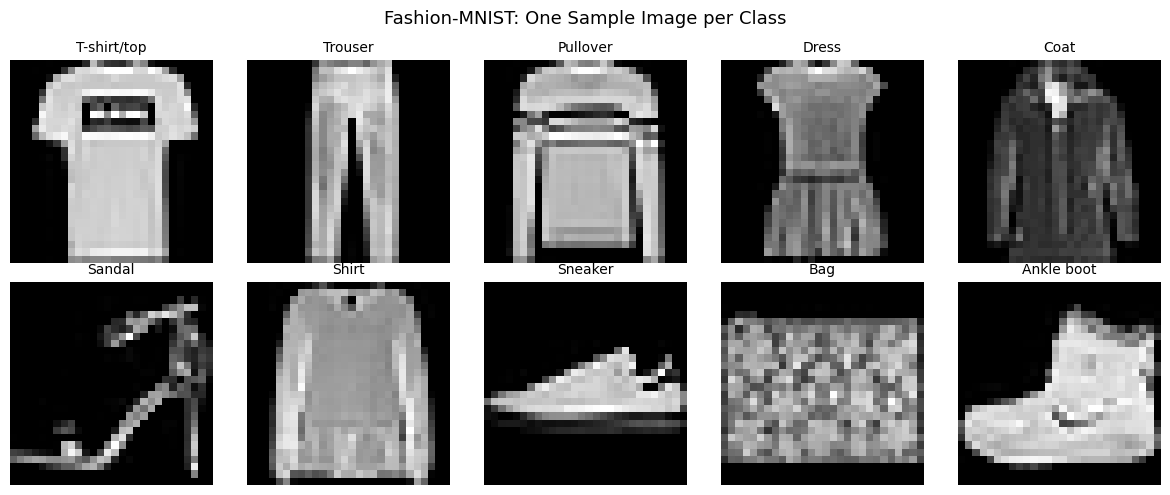

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(CLASS_NAMES[i], fontsize=10)
    ax.axis('off')
plt.suptitle("Fashion-MNIST: One Sample Image per Class", fontsize=13)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=130, bbox_inches='tight')
plt.show()

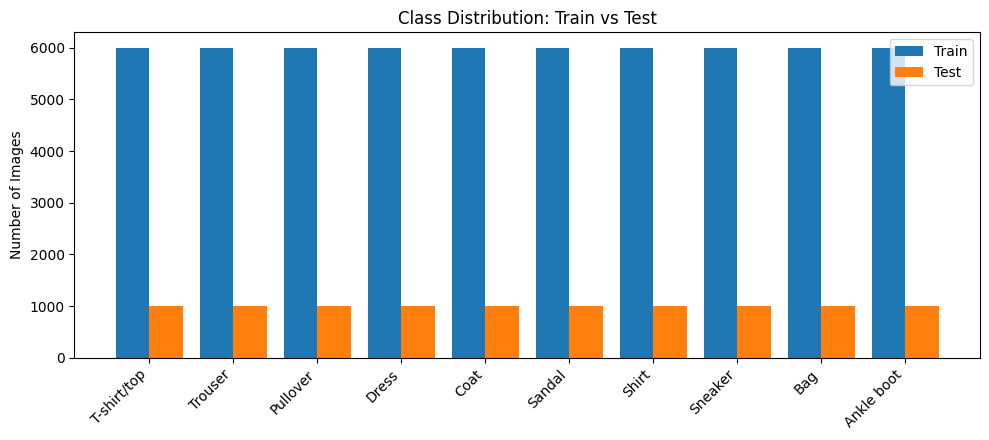

{0: 6000, 1: 6000, 2: 6000, 3: 6000, 4: 6000, 5: 6000, 6: 6000, 7: 6000, 8: 6000, 9: 6000}
{0: 1000, 1: 1000, 2: 1000, 3: 1000, 4: 1000, 5: 1000, 6: 1000, 7: 1000, 8: 1000, 9: 1000}


In [5]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
width = 0.4
xpos = np.arange(10)
ax.bar(xpos - width/2, train_counts.values, width, label='Train')
ax.bar(xpos + width/2, test_counts.values, width, label='Test')
ax.set_xticks(xpos)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('Number of Images')
ax.set_title('Class Distribution: Train vs Test')
ax.legend()
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

print(train_counts.to_dict())
print(test_counts.to_dict())

In [6]:
print("Shape before preprocessing:", x_train.shape, x_train.dtype)

x_train_flat = x_train.reshape(x_train.shape[0], -1).astype('float32')
x_test_flat = x_test.reshape(x_test.shape[0], -1).astype('float32')

x_train_flat /= 255.0
x_test_flat /= 255.0

y_train_oh = keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

print("Shape after preprocessing:", x_train_flat.shape, x_train_flat.dtype)
print("Pixel range after normalization:", x_train_flat.min(), "-", x_train_flat.max())
print("Label shape before one-hot:", y_train.shape, " -> after one-hot:", y_train_oh.shape)

Shape before preprocessing: (60000, 28, 28) uint8
Shape after preprocessing: (60000, 784) float32
Pixel range after normalization: 0.0 - 1.0
Label shape before one-hot: (60000,)  -> after one-hot: (60000, 10)


In [7]:
def build_baseline_model():
    model = keras.Sequential([
        keras.layers.Input(shape=(784,), name='input_784'),
        keras.layers.Dense(128, activation='relu', name='dense_128'),
        keras.layers.Dense(64, activation='relu', name='dense_64'),
        keras.layers.Dense(10, activation='softmax', name='output_softmax'),
    ], name='baseline_MLP')
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "baseline_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_128 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
baseline_history = baseline_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=2
)
baseline_train_time = time.time() - t0
print(f"\nBaseline training time: {baseline_train_time:.2f} seconds")

Epoch 1/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8213 - loss: 0.5005 - val_accuracy: 0.8527 - val_loss: 0.3959
Epoch 2/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8642 - loss: 0.3722 - val_accuracy: 0.8572 - val_loss: 0.3811
Epoch 3/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8773 - loss: 0.3332 - val_accuracy: 0.8603 - val_loss: 0.3772
Epoch 4/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8855 - loss: 0.3084 - val_accuracy: 0.8640 - val_loss: 0.3708
Epoch 5/20
1688/1688 - 6s - 3ms/step - accuracy: 0.8924 - loss: 0.2905 - val_accuracy: 0.8685 - val_loss: 0.3607
Epoch 6/20
1688/1688 - 7s - 4ms/step - accuracy: 0.8979 - loss: 0.2751 - val_accuracy: 0.8708 - val_loss: 0.3647
Epoch 7/20
1688/1688 - 10s - 6ms/step - accuracy: 0.9026 - loss: 0.2613 - val_accuracy: 0.8708 - val_loss: 0.3747
Epoch 8/20
1688/1688 - 9s - 5ms/step - accuracy: 0.9063 - loss: 0.2510 - val_accuracy: 0.8743 - val_loss: 0.3733
Epoch 9/20
1688/1688 - 7s - 4ms/step - accuracy: 0.9097 - loss: 0.2407 - val_accuracy: 0.8763 -

In [9]:
y_pred_prob = baseline_model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

baseline_acc = accuracy_score(y_test, y_pred)
baseline_prec = precision_score(y_test, y_pred, average='macro')
baseline_rec = recall_score(y_test, y_pred, average='macro')
baseline_f1 = f1_score(y_test, y_pred, average='macro')
baseline_cm = confusion_matrix(y_test, y_pred)

print(f"Test Accuracy  : {baseline_acc:.4f}")
print(f"Precision(macro): {baseline_prec:.4f}")
print(f"Recall(macro)   : {baseline_rec:.4f}")
print(f"F1-score(macro) : {baseline_f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Test Accuracy  : 0.8807
Precision(macro): 0.8830
Recall(macro)   : 0.8807
F1-score(macro) : 0.8786

Classification Report:

              precision    recall  f1-score   support

 T-shirt/top       0.77      0.90      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.76      0.81      0.78      1000
       Dress       0.88      0.90      0.89      1000
        Coat       0.76      0.82      0.79      1000
      Sandal       0.97      0.97      0.97      1000
       Shirt       0.82      0.56      0.67      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



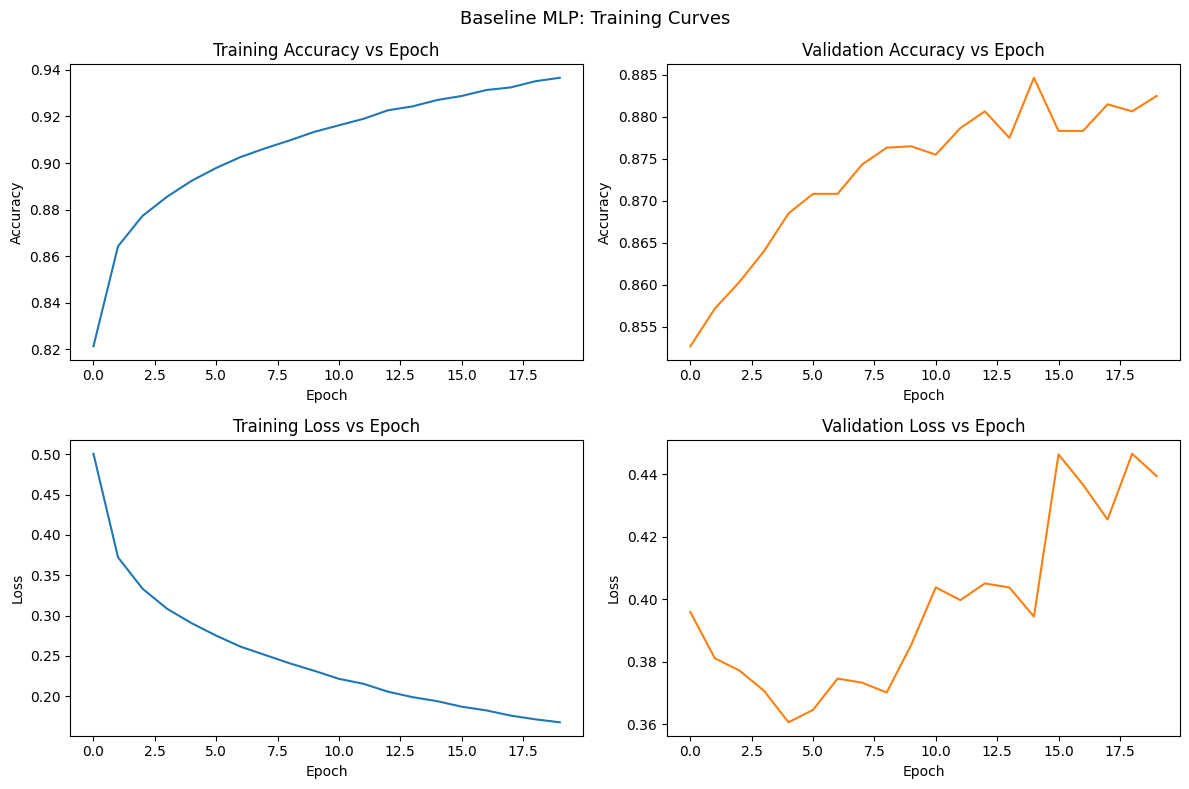

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].plot(baseline_history.history['accuracy'], color='tab:blue')
axes[0,0].set_title('Training Accuracy vs Epoch')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Accuracy')

axes[0,1].plot(baseline_history.history['val_accuracy'], color='tab:orange')
axes[0,1].set_title('Validation Accuracy vs Epoch')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Accuracy')

axes[1,0].plot(baseline_history.history['loss'], color='tab:blue')
axes[1,0].set_title('Training Loss vs Epoch')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Loss')

axes[1,1].plot(baseline_history.history['val_loss'], color='tab:orange')
axes[1,1].set_title('Validation Loss vs Epoch')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Loss')

plt.suptitle('Baseline MLP: Training Curves', fontsize=13)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=130, bbox_inches='tight')
plt.show()

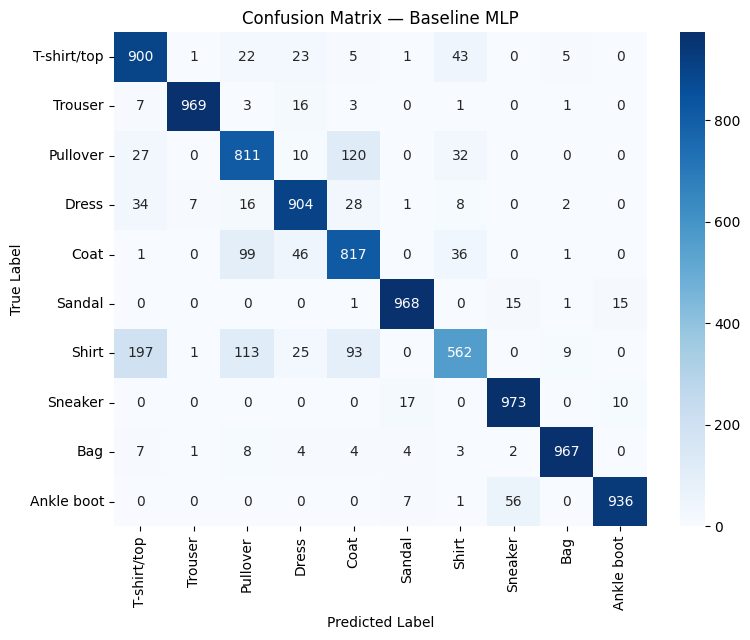

In [11]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(baseline_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Baseline MLP')
plt.tight_layout()
plt.savefig('confusion_matrix_baseline.png', dpi=130, bbox_inches='tight')
plt.show()

In [12]:
def build_search_model(hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
                        optimizer_name='adam', activation='relu', dropout_rate=0.0):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(keras.layers.Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(keras.layers.Dropout(dropout_rate))
    model.add(keras.layers.Dense(10, activation='softmax'))

    if optimizer_name == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = keras.optimizers.Adam(learning_rate=learning_rate)

    # SciKeras/RandomizedSearchCV pass integer class labels (not one-hot),
    # so we use sparse_categorical_crossentropy here.
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

clf = KerasClassifier(
    model=build_search_model,
    hidden_layers=2, hidden_neurons=64, learning_rate=0.001,
    optimizer_name='adam', activation='relu', dropout_rate=0.0,
    epochs=10, batch_size=32, verbose=0
)

param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30],
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5],
}

In [13]:
x_search, _, y_search, _ = train_test_split(
    x_train_flat, y_train, train_size=6000, stratify=y_train, random_state=SEED
)

search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    random_state=SEED,
    n_jobs=1,
    verbose=2,
)

t0 = time.time()
search.fit(x_search, y_search)
search_time = time.time() - t0

print(f"\nHyperparameter search time: {search_time:.2f} seconds")
print("Best CV accuracy:", search.best_score_)
print("Best parameters :", search.best_params_)

cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
cv_results[['rank_test_score','mean_test_score','std_test_score','params']].to_csv('cv_results.csv', index=False)
cv_results[['rank_test_score','mean_test_score','std_test_score','params']]

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=  22.4s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   9.3s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   7.3s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   8.1s
[CV] END activation=tanh, batch_size=128, dropout_rate=0.2, epochs=20, hidden_layers=1, hidden_neurons=256, learning_rate=0.001, optimizer_name=adam; total time=   7.2s
[CV] END activation=relu, batch_size=16, dropout_rate=0.5, epochs=20, hidden_layers=3, hidden_

,rank_test_score,mean_test_score,std_test_score,params
7,1,0.843167,0.008239,"{'optimizer_name': 'adam', 'learning_rate': 0...."
0,2,0.833667,0.008003,"{'optimizer_name': 'adam', 'learning_rate': 0...."
4,3,0.830167,0.010883,"{'optimizer_name': 'adam', 'learning_rate': 0...."
2,4,0.828833,0.002147,"{'optimizer_name': 'rmsprop', 'learning_rate':..."
3,5,0.827667,0.002759,"{'optimizer_name': 'adam', 'learning_rate': 0...."
8,6,0.827333,0.013988,"{'optimizer_name': 'adam', 'learning_rate': 0...."
9,7,0.822833,0.011126,"{'optimizer_name': 'adam', 'learning_rate': 0...."
6,8,0.658000,0.019802,"{'optimizer_name': 'adam', 'learning_rate': 0...."
1,9,0.629000,0.028506,"{'optimizer_name': 'rmsprop', 'learning_rate':..."
5,10,0.383333,0.061298,"{'optimizer_name': 'adam', 'learning_rate': 0...."


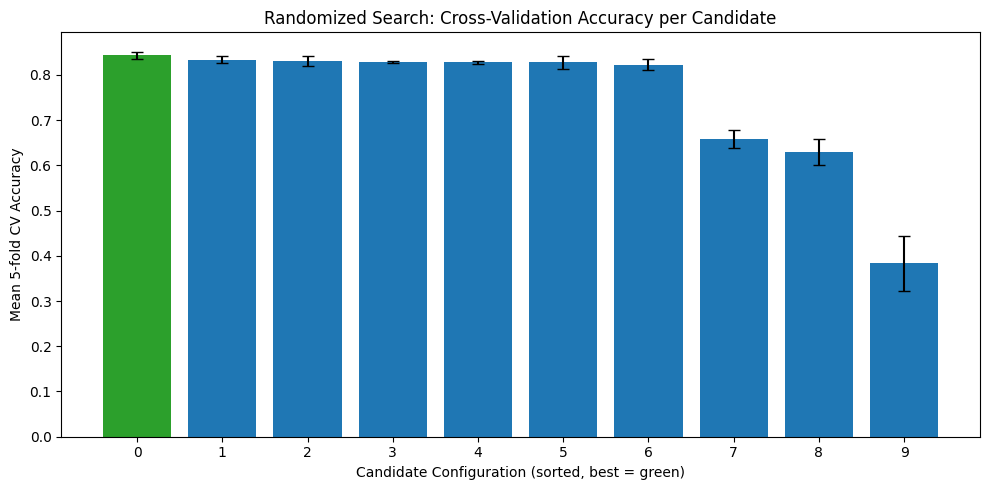

In [14]:
results_sorted = pd.DataFrame(search.cv_results_).sort_values('mean_test_score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tab:green' if i == 0 else 'tab:blue' for i in range(len(results_sorted))]
ax.bar(range(len(results_sorted)), results_sorted['mean_test_score'],
       yerr=results_sorted['std_test_score'], color=colors, capsize=4)
ax.set_xlabel('Candidate Configuration (sorted, best = green)')
ax.set_ylabel('Mean 5-fold CV Accuracy')
ax.set_title('Randomized Search: Cross-Validation Accuracy per Candidate')
ax.set_xticks(range(len(results_sorted)))
plt.tight_layout()
plt.savefig('hyperparam_search_results.png', dpi=130, bbox_inches='tight')
plt.show()

In [15]:
best_params = search.best_params_
print("Best hyperparameters selected by RandomizedSearchCV:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

def build_final_model(params):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(784,)))
    for _ in range(params['hidden_layers']):
        model.add(keras.layers.Dense(params['hidden_neurons'], activation=params['activation']))
        if params['dropout_rate'] > 0:
            model.add(keras.layers.Dropout(params['dropout_rate']))
    model.add(keras.layers.Dense(10, activation='softmax'))

    if params['optimizer_name'] == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=params['learning_rate'])
    elif params['optimizer_name'] == 'rmsprop':
        opt = keras.optimizers.RMSprop(learning_rate=params['learning_rate'])
    else:
        opt = keras.optimizers.Adam(learning_rate=params['learning_rate'])

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

optimized_model = build_final_model(best_params)
optimized_model.summary()

t0 = time.time()
optimized_history = optimized_model.fit(
    x_train_flat, y_train_oh,
    validation_split=0.1,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    verbose=2
)
optimized_train_time = time.time() - t0
print(f"\nOptimized model training time: {optimized_train_time:.2f} seconds")

Best hyperparameters selected by RandomizedSearchCV:
  optimizer_name: adam
  learning_rate: 0.001
  hidden_neurons: 256
  hidden_layers: 1
  epochs: 20
  dropout_rate: 0.2
  batch_size: 16
  activation: relu


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_142 (Dense)               │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3375/3375 - 17s - 5ms/step - accuracy: 0.8140 - loss: 0.5151 - val_accuracy: 0.8495 - val_loss: 0.4094
Epoch 2/20
3375/3375 - 17s - 5ms/step - accuracy: 0.8548 - loss: 0.3979 - val_accuracy: 0.8672 - val_loss: 0.3639
Epoch 3/20
3375/3375 - 16s - 5ms/step - accuracy: 0.8673 - loss: 0.3611 - val_accuracy: 0.8697 - val_loss: 0.3572
Epoch 4/20
3375/3375 - 15s - 5ms/step - accuracy: 0.8746 - loss: 0.3414 - val_accuracy: 0.8758 - val_loss: 0.3448
Epoch 5/20
3375/3375 - 15s - 5ms/step - accuracy: 0.8803 - loss: 0.3242 - val_accuracy: 0.8780 - val_loss: 0.3483
Epoch 6/20
3375/3375 - 15s - 5ms/step - accuracy: 0.8854 - loss: 0.3106 - val_accuracy: 0.8758 - val_loss: 0.3474
Epoch 7/20
3375/3375 - 20s - 6ms/step - accuracy: 0.8880 - loss: 0.2994 - val_accuracy: 0.8767 - val_loss: 0.3341
Epoch 8/20
3375/3375 - 21s - 6ms/step - accuracy: 0.8918 - loss: 0.2904 - val_accuracy: 0.8833 - val_loss: 0.3302
Epoch 9/20
3375/3375 - 15s - 4ms/step - accuracy: 0.8939 - loss: 0.2834 - val_accuracy: 

In [16]:
y_pred_prob_opt = optimized_model.predict(x_test_flat, verbose=0)
y_pred_opt = np.argmax(y_pred_prob_opt, axis=1)

optimized_acc = accuracy_score(y_test, y_pred_opt)
optimized_prec = precision_score(y_test, y_pred_opt, average='macro')
optimized_rec = recall_score(y_test, y_pred_opt, average='macro')
optimized_f1 = f1_score(y_test, y_pred_opt, average='macro')
optimized_cm = confusion_matrix(y_test, y_pred_opt)

print(f"Optimized Test Accuracy  : {optimized_acc:.4f}")
print(f"Optimized Precision(macro): {optimized_prec:.4f}")
print(f"Optimized Recall(macro)   : {optimized_rec:.4f}")
print(f"Optimized F1-score(macro) : {optimized_f1:.4f}")
print("\nClassification Report (Optimized Model):\n")
print(classification_report(y_test, y_pred_opt, target_names=CLASS_NAMES))

Optimized Test Accuracy  : 0.8833
Optimized Precision(macro): 0.8848
Optimized Recall(macro)   : 0.8833
Optimized F1-score(macro) : 0.8811

Classification Report (Optimized Model):

              precision    recall  f1-score   support

 T-shirt/top       0.82      0.87      0.84      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.77      0.83      0.80      1000
       Dress       0.79      0.95      0.87      1000
        Coat       0.81      0.79      0.80      1000
      Sandal       0.96      0.97      0.97      1000
       Shirt       0.82      0.58      0.68      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [17]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)', 'Training Time (s)'],
    'Baseline': [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_train_time],
    'Optimized': [optimized_acc, optimized_prec, optimized_rec, optimized_f1, optimized_train_time],
})
comparison.to_csv('comparison.csv', index=False)
comparison

,Metric,Baseline,Optimized
0,Accuracy,0.880700,0.883300
1,Precision (macro),0.882990,0.884827
2,Recall (macro),0.880700,0.883300
3,F1-score (macro),0.878615,0.881136
4,Training Time (s),143.268372,327.732573


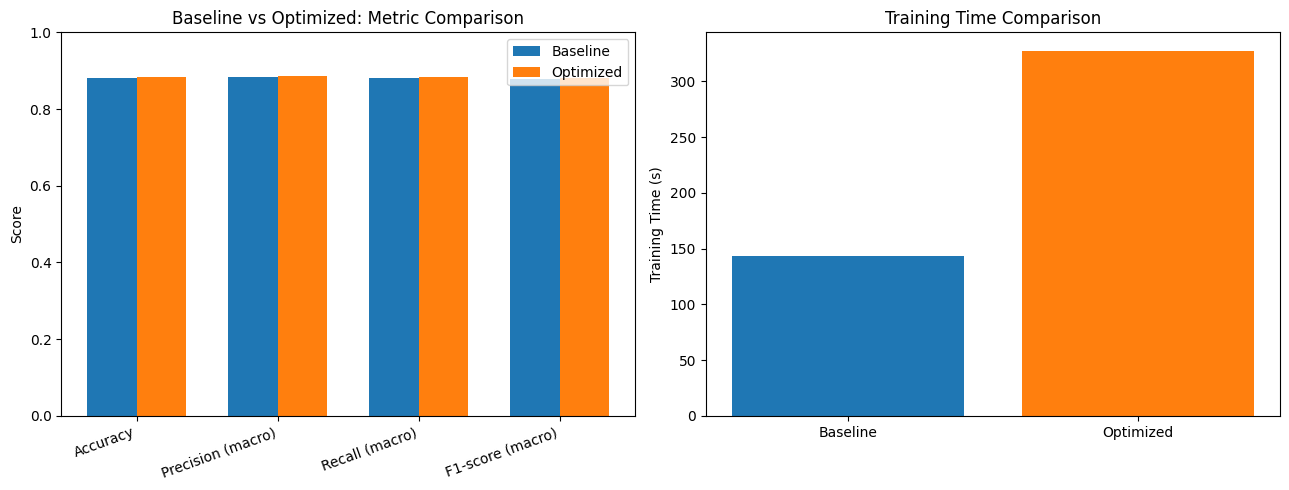

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-score (macro)']
xpos = np.arange(len(metrics))
width = 0.35
axes[0].bar(xpos - width/2, comparison.loc[comparison['Metric'].isin(metrics), 'Baseline'], width, label='Baseline')
axes[0].bar(xpos + width/2, comparison.loc[comparison['Metric'].isin(metrics), 'Optimized'], width, label='Optimized')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(metrics, rotation=20, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].set_title('Baseline vs Optimized: Metric Comparison')
axes[0].legend()

axes[1].bar(['Baseline', 'Optimized'], [baseline_train_time, optimized_train_time],
            color=['tab:blue', 'tab:orange'])
axes[1].set_ylabel('Training Time (s)')
axes[1].set_title('Training Time Comparison')

plt.tight_layout()
plt.savefig('best_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

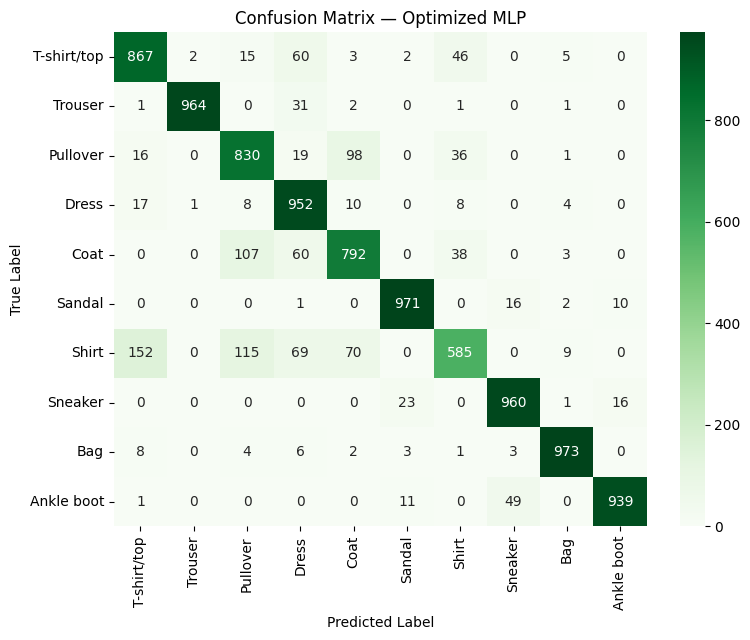

In [19]:
plt.figure(figsize=(8, 6.5))
sns.heatmap(optimized_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix — Optimized MLP')
plt.tight_layout()
plt.savefig('confusion_matrix_optimized.png', dpi=130, bbox_inches='tight')
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

# ==========================================
# Task 1: Dataset Exploration
# ==========================================
print("--- Task 1: Dataset Exploration ---")
# Load Fashion-MNIST
fashion_mnist = tf.keras.datasets.fashion_mnist
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = fashion_mnist.load_data()

# Print dataset dimensions
print(f"Training Data Shape: {X_train_raw.shape}")
print(f"Testing Data Shape: {X_test_raw.shape}")

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Plot 1. Display ten sample images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.title(class_names[y_train_raw[i]])
    plt.axis('off')
plt.suptitle("Task 1: Ten Sample Images")
plt.tight_layout()
plt.show()
# Inference: Images are 28x28 grayscale representations of various clothing items, distinct enough for classification.

# Plot 2. Plot class distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train_raw)
plt.title("Task 1: Class Distribution in Training Set")
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.xlabel("Clothing Class")
plt.ylabel("Frequency")
plt.show()
# Inference: The dataset is perfectly balanced, with 6,000 samples per class, ensuring no class bias during training.

# ==========================================
# Task 2: Data Preprocessing
# ==========================================
print("\n--- Task 2: Data Preprocessing ---")
# Flatten images & Normalize pixel values to [0,1]
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# Convert labels into one-hot vectors
y_train = to_categorical(y_train_raw, 10)
y_test = to_categorical(y_test_raw, 10)

print(f"Tensor shape before preprocessing: {X_train_raw.shape}")
print(f"Tensor shape after preprocessing (flattened): {X_train.shape}")

# ==========================================
# Task 3: Model Construction (Baseline)
# ==========================================
print("\n--- Task 3: Model Construction ---")
baseline_model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
baseline_model.summary()

# ==========================================
# Task 4: Model Training
# ==========================================
print("\n--- Task 4: Model Training ---")
baseline_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

# Train for 20 epochs with batch size 32. Reserving 20% for validation to plot curves.
history = baseline_model.fit(X_train, y_train,
                             epochs=20,
                             batch_size=32,
                             validation_split=0.2,
                             verbose=1)

# Plots 3-6: Training/Validation Accuracy and Loss
plt.figure(figsize=(14, 5))
# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Task 4: Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Inference: Training accuracy steadily increases, while validation accuracy plateaus, indicating mild overfitting after early epochs.

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Task 4: Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
# Inference: Validation loss diverges slightly from training loss in later epochs, corroborating the presence of overfitting.

# ==========================================
# Task 5: Model Evaluation
# ==========================================
print("\n--- Task 5: Model Evaluation ---")
y_pred_probs = baseline_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test_raw, y_pred)
prec = precision_score(y_test_raw, y_pred, average='weighted')
rec = recall_score(y_test_raw, y_pred, average='weighted')
f1 = f1_score(y_test_raw, y_pred, average='weighted')

print(f"Baseline Model Accuracy: {acc:.4f}")
print(f"Baseline Model Precision: {prec:.4f}")
print(f"Baseline Model Recall: {rec:.4f}")
print(f"Baseline Model F1-Score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test_raw, y_pred, target_names=class_names))

# Plot 7: Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_raw, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Task 5: Confusion Matrix (Baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
# Inference: The model struggles most with distinguishing visually similar items, such as 'Shirt' and 'T-shirt/top'.

# ==========================================
# Task 7: Hyperparameter Optimization
# ==========================================
print("\n--- Hyperparameter Optimization ---")

# Dynamic model builder for SciKeras
def build_mlp(hidden_layers=1, hidden_neurons=64, learning_rate=0.001,
              optimizer_name='adam', activation_fn='relu', dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation_fn))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation='softmax'))

    # Configure optimizer
    if optimizer_name == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        opt = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Wrap model
keras_clf = KerasClassifier(
    model=build_mlp,
    verbose=0,
    hidden_layers=1, hidden_neurons=64, learning_rate=0.001,
    optimizer_name='adam', activation_fn='relu', dropout_rate=0.0,
    epochs=10, batch_size=32 # Defaults
)

# Search space defined in the manual
param_dist = {
    'hidden_layers': [1, 2, 3],
    'hidden_neurons': [32, 64, 128, 256],
    'learning_rate': [0.1, 0.01, 0.001],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20], # Reduced search space to 10 and 20 for computational sanity in Colab
    'optimizer_name': ['sgd', 'adam', 'rmsprop'],
    'activation_fn': ['relu', 'tanh', 'sigmoid'],
    'dropout_rate': [0.0, 0.2, 0.5]
}

# Use RandomizedSearchCV with 5-fold CV.
# NOTE: n_iter is set to 3 to keep Colab runtime manageable. Increase for a deeper search.
random_search = RandomizedSearchCV(estimator=keras_clf, param_distributions=param_dist,
                                   n_iter=3, cv=5, n_jobs=1, verbose=2, random_state=42)

print("Starting Randomized Search (this may take a few minutes)...")
random_search_result = random_search.fit(X_train[:10000], y_train[:10000]) # Using subset of data to speed up search in Colab

print("\nBest Hyperparameters found:")
print(random_search_result.best_params_)
best_params = random_search_result.best_params_

# Retrain using the best hyperparameters on FULL training data
print("\nRetraining Best Model on full dataset...")
best_model = build_mlp(
    hidden_layers=best_params['hidden_layers'],
    hidden_neurons=best_params['hidden_neurons'],
    learning_rate=best_params['learning_rate'],
    optimizer_name=best_params['optimizer_name'],
    activation_fn=best_params['activation_fn'],
    dropout_rate=best_params['dropout_rate']
)

history_best = best_model.fit(X_train, y_train,
                              epochs=best_params['epochs'],
                              batch_size=best_params['batch_size'],
                              validation_split=0.2, verbose=1)

# Evaluate Best Model
y_pred_best_probs = best_model.predict(X_test)
y_pred_best = np.argmax(y_pred_best_probs, axis=1)
opt_acc = accuracy_score(y_test_raw, y_pred_best)

# Plot 9: Best Model Accuracy Comparison
plt.figure(figsize=(6, 5))
sns.barplot(x=['Baseline', 'Optimized'], y=[acc, opt_acc])
plt.title("Task 8: Best Model Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.0)
plt.show()
# Inference: Compares the baseline model directly against the cross-validated optimized model to illustrate performance gains.

--- Task 1: Dataset Exploration ---
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)

--- Task 2: Data Preprocessing ---
Tensor shape before preprocessing: (60000, 28, 28)
Tensor shape after preprocessing (flattened): (60000, 784)

--- Task 3: Model Construction ---


Model: "sequential_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_196 (Dense)               │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_197 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_198 (Dense)               │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


--- Task 4: Model Training ---
Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.8183 - loss: 0.5132 - val_accuracy: 0.8517 - val_loss: 0.4149
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8625 - loss: 0.3785 - val_accuracy: 0.8608 - val_loss: 0.3793
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8759 - loss: 0.3388 - val_accuracy: 0.8692 - val_loss: 0.3641
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8844 - loss: 0.3137 - val_accuracy: 0.8760 - val_loss: 0.3492
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8909 - loss: 0.2948 - val_accuracy: 0.8792 - val_loss: 0.3446
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8961 - loss: 0.2774 - val_accuracy: 0.8786 - val_loss: 0.3435
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9003 - loss: 0.2633 - val_accuracy: 0.8769 - val_loss: 0.3534
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step -